# 1주차 코딩실습 정답
현재 배포된 1주차 실습문제 5개의 완성 코드, 실행 결과와 해설입니다.

In [1]:
import torch
import matplotlib.pyplot as plt
torch.manual_seed(0)

## 문제 1. 텐서의 통계량과 모양 변경

In [2]:
values = torch.arange(1, 13, dtype=torch.float32)
matrix = values.reshape(3, 4)
column_mean = matrix.mean(dim=0)
print(matrix)
print(column_mean)

tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.]])
tensor([5., 6., 7., 8.])


## 문제 2. 행렬 곱과 요소별 곱 비교

In [3]:
A = torch.tensor([[1., 2.], [3., 4.]])
B = torch.tensor([[2., 0.], [1., 2.]])
elementwise = A * B
matmul = A @ B
print('elementwise:\n', elementwise)
print('matmul:\n', matmul)

elementwise:
 tensor([[2., 0.],
        [3., 8.]])
matmul:
 tensor([[ 4.,  4.],
        [10.,  8.]])


두 연산 모두 2×2 텐서를 만들지만, 요소별 곱은 같은 위치끼리 곱하고 행렬 곱은 행과 열의 내적을 계산하므로 값이 다릅니다.

## 문제 3. 브로드캐스팅으로 표준화

In [4]:
X = torch.tensor([[1., 10., 100.], [2., 20., 120.],
                  [3., 30., 140.], [4., 40., 160.]])
mean = X.mean(dim=0)
std = X.std(dim=0)
standardized = (X - mean) / std
print(standardized)
print('mean:', standardized.mean(dim=0))
print('std:', standardized.std(dim=0))

tensor([[-1.1619, -1.1619, -1.1619],
        [-0.3873, -0.3873, -0.3873],
        [ 0.3873,  0.3873,  0.3873],
        [ 1.1619,  1.1619,  1.1619]])
mean: tensor([0., 0., 0.])
std: tensor([1., 1., 1.])


## 문제 4. 자동미분으로 기울기 확인

In [5]:
x = torch.tensor(2.0)
y_true = torch.tensor(4.0)
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)
y_pred = w * x + b
loss = (y_pred - y_true) ** 2
loss.backward()
print('loss:', loss.item(), 'grad_w:', w.grad.item(), 'grad_b:', b.grad.item())

loss: 8.410000801086426 grad_w: -11.600000381469727 grad_b: -5.800000190734863


## 문제 5. 활성화 함수 비교 시각화

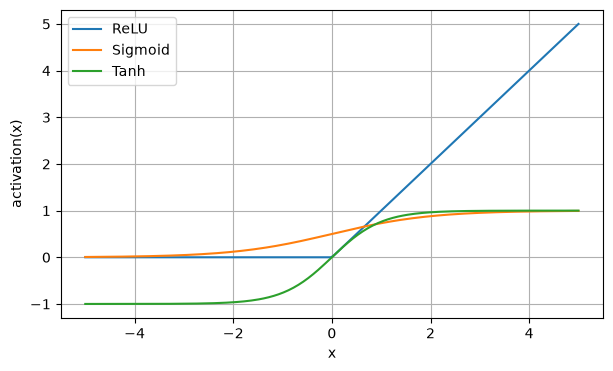

In [6]:
x = torch.linspace(-5, 5, steps=200)
y_relu = torch.relu(x)
y_sigmoid = torch.sigmoid(x)
y_tanh = torch.tanh(x)
plt.figure(figsize=(7, 4))
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.xlabel('x'); plt.ylabel('activation(x)')
plt.legend(); plt.grid(True); plt.show()

ReLU의 출력 범위는 [0, ∞)이며 음수 입력을 0으로 만듭니다. Sigmoid는 (0, 1), Tanh는 (-1, 1) 범위입니다. Tanh는 음수 입력을 음수로 유지하지만 Sigmoid는 모든 출력을 양수로 만듭니다.